# COC Base Designer

## Config and Import

In [10]:
import sys
print(sys.executable)

c:\Users\widia\miniconda3\envs\coc\python.exe


In [11]:
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)



NumPy : 2.4.6
Pandas: 3.0.5
Matplotlib: 3.11.0


In [12]:
# backup
# !conda env export --no-builds > environment.yml

# restore
# conda env create -f environment.yml

In [13]:
from pathlib import Path
PATH = Path('C:/xampp/htdocs/coc-base-designer')

path_output = PATH / "output"
path_output.mkdir(parents=True, exist_ok=True)

print(path_output)


C:\xampp\htdocs\coc-base-designer\output


In [14]:
MAP_SIZE = 44

# Matriks kosong
base = np.zeros((MAP_SIZE, MAP_SIZE), dtype=int)

print(base.shape)

buildings = pd.read_csv(
    PATH / "data" / "buildings.csv",
    sep=";"
)
buildings.columns = (
    buildings.columns
    .str.strip()      # hapus spasi depan/belakang
    .str.lower()      # ubah ke huruf kecil
)

(44, 44)


In [15]:
# print(buildings.columns.tolist())
print(buildings.head())
print('--------------------------------')
print(buildings.info())
print('--------------------------------')
print(buildings.columns.tolist())


   id code   name  level   dps  damage_per_hit  hitpoints build_cost  \
0   1   CN  Canon      1   7.0             5.6      300.0        250   
1   1   CN  Canon      2  10.0             8.0      360.0          1   
2   1   CN  Canon      3  13.0            10.4      420.0          4   
3   1   CN  Canon      4  17.0            13.6      500.0         16   
4   1   CN  Canon      5  23.0            18.4      600.0         50   

  build_time  experience  required_th size  min_range  max_range attack_speed  \
0         5s         2.0            1  3x3        9.0        9.0         0.8s   
1        30s         5.0            1  3x3        9.0        9.0         0.8s   
2         2m        10.0            2  3x3        9.0        9.0         0.8s   
3        20m        34.0            3  3x3        9.0        9.0         0.8s   
4        30m        42.0            4  3x3        9.0        9.0         0.8s   

     damage_type target_type  max_count  
0  Single Target      Ground          

## Function


In [16]:
def can_place(matrix, row, col, width, height):
    """
    Mengecek apakah area masih kosong.
    """
    # Keluar dari batas map
    if row < 0 or col < 0:
        return False

    if row + height > matrix.shape[0]:
        return False

    if col + width > matrix.shape[1]:
        return False

    area = matrix[row:row+height, col:col+width]

    return np.all(area == 0)

# Fungsi meletakkan bangunan
def place_building(matrix, row, col, width, height, value):

    # if not can_place(matrix, row, col, width, height):
    #     raise ValueError(
    #         f"Bangunan bertabrakan atau keluar map pada "
    #         f"row={row}, col={col}"
    #     )

    matrix[row:row+height, col:col+width] = value

# 3x3 to w=3,h=3
def parse_size(size):
    width, height = size.lower().split("x")
    return int(width), int(height)
    
def get_building(code):
    row = buildings.loc[buildings["code"] == code]

    if row.empty:
        raise ValueError(f"Building '{code}' tidak ditemukan.")

    row = row.iloc[0].to_dict()

    width, height = parse_size(row["size"])

    row["width"] = width
    row["height"] = height

    return row

def show_map(base, annotations=None):
    # =============================
    # Plot
    # =============================
    fig, ax = plt.subplots(figsize=(10,10))

    ax.imshow(
        base,
        cmap="tab20",
        origin="upper",
        interpolation="none"
    )

    # Grid
    # Major ticks (angka koordinat)
    ax.set_xticks(np.arange(MAP_SIZE))
    ax.set_yticks(np.arange(MAP_SIZE))

    ax.set_xticklabels(np.arange(MAP_SIZE), fontsize=8)
    ax.set_yticklabels(np.arange(MAP_SIZE), fontsize=8)

    # Minor ticks (garis grid)
    ax.set_xticks(np.arange(-0.5, MAP_SIZE, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, MAP_SIZE, 1), minor=True)

    ax.grid(
        which="minor",
        color="lightgray",
        linestyle="-",
        linewidth=0.5
    )

    # Tampilkan angka di atas
    ax.xaxis.tick_top()

    # Hilangkan tanda tick (garis kecil)
    ax.tick_params(
        which="major",
        length=0
    )

    ax.set_title("Town Hall 2 Layout")

    if annotations is not None:
        for ann in annotations:
            center_x = ann["col"] + ann["width"]/2 - 0.5
            center_y = ann["row"] + ann["height"]/2 - 0.5

            ax.text(
                center_x,
                center_y,
                ann["text"],
                ha="center",
                va="center",
                fontsize=8,
                color="black",
                weight="bold"
            )

    plt.tight_layout()
    plt.show()

    return fig,ax


## Layout

In [ ]:
layout = {
    "townhall_level": 2,
    "buildings": [
        {
            "code": "TH",
            "level": 2,
            "row": 20,
            "col": 20
        },
        {
            "code": "CN",
            "row": 15,
            "col": 15
        },
        {
            "code": "CN",
            "row": 15,
            "col": 25
        },
        {
            "code": "AT",
            "row": 28,
            "col": 20
        }
    ],
    "walls": [
        {"row":19,"col":19},
        {"row":19,"col":20},
        {"row":19,"col":21},
        {"row":19,"col":22},
        {"row":19,"col":23},
        {"row":19,"col":24},

        {"row":24,"col":19},
        {"row":24,"col":20},
        {"row":24,"col":21},
        {"row":24,"col":22},
        {"row":24,"col":23},
        {"row":24,"col":24},

        {"row":20,"col":19},
        {"row":21,"col":19},
        {"row":22,"col":19},
        {"row":23,"col":19},

        {"row":20,"col":24},
        {"row":21,"col":24},
        {"row":22,"col":24},
        {"row":23,"col":24},
    ]
}

## Show

### Layer 1

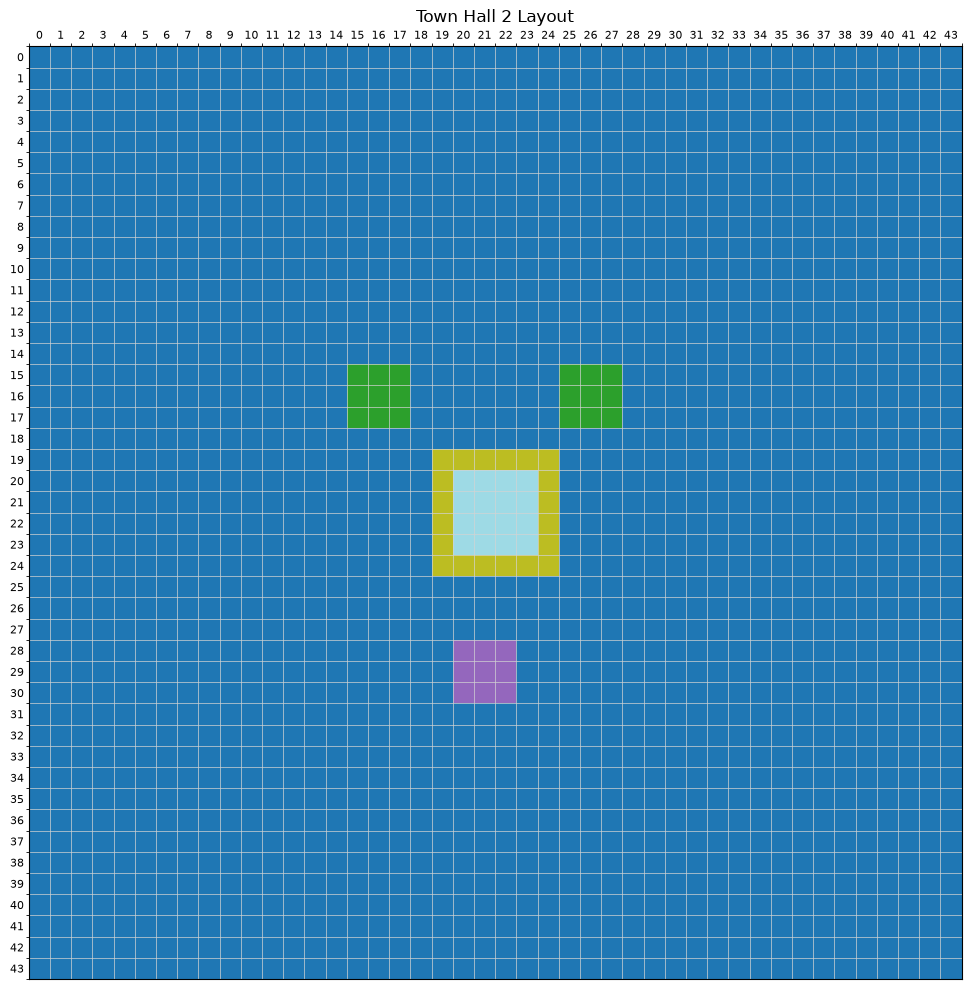

In [43]:
for b in layout["buildings"]:
    building = get_building(b["code"])

    place_building(
        base,
        b["row"],
        b["col"],
        building["width"],
        building["height"],
        building["id"]
    )

wall = get_building("WLL")

for w in layout["walls"]:
    place_building(
        base,
        w["row"],
        w["col"],
        wall["width"],
        wall["height"],
        wall["id"]
    )



fig, ax = show_map(base)

### Layer 2

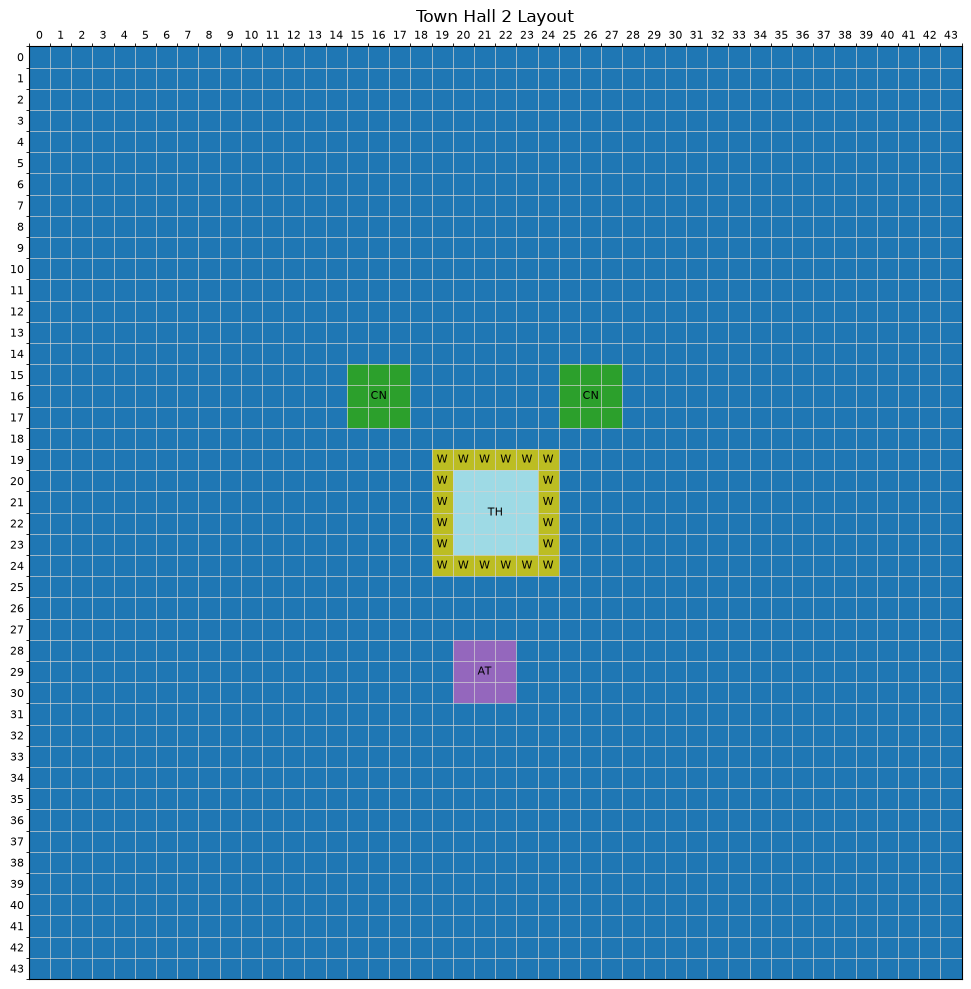

In [44]:
annotations = []
for b in layout["buildings"]:

    building = get_building(b["code"])

    annotations.append({
        "text":building["code"],
        "row":b["row"],
        "col":b["col"],
        "width":building["width"],
        "height":building["height"]
    })
    
for w in layout["walls"]:
    annotations.append({
        "text": "W",
        "row": w["row"],
        "col": w["col"],
        "width": wall["width"],
        "height": wall["height"]
    })
fig, ax = show_map(base, annotations)


## Save Output

In [45]:
def save_map(fig,filename):
    try:
        save_path = path_output / filename
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Map berhasil disimpan di: {save_path.resolve()}")
    except Exception as e:
        print(f"Gagal menyimpan map: {e}")

save_map(fig, "th2.png")

Map berhasil disimpan di: C:\xampp\htdocs\coc-base-designer\output\th2.png
